In [ ]:
1

1

In [1]:
import numpy as np
import time as tt
import matplotlib.pyplot as plt
import pyJHTDB

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 100000
from pyJHTDB.dbinfo import interpolation_code


time = 3.3

# load shared library
lTDB = pyJHTDB.libJHTDB()
#initialize webservices
lTDB.initialize()

#Add token
auth_token  = "edu.jhu.pha.turbulence.testing-201311"  #Replace with your own token here
lTDB.add_token(auth_token)

# Grid parameters
grid_min_x = 0
grid_max_x = 2. * np.pi
grid_min_y = 0  # New parameter for y-dimension
grid_max_y = 2. * np.pi  # New parameter for y-dimension
grid_min_z =  0
grid_max_z = 2. * np.pi

# Calculate the grid spacing to achieve 2 million points
target_points = 2000000
grid_spacing = (grid_max_x - grid_min_x) / (np.cbrt(target_points))

# Calculate the number of points in each dimension
num_points_x = int((grid_max_x - grid_min_x) / grid_spacing)
num_points_y = int((grid_max_y - grid_min_y) / grid_spacing)  # New line for y-dimension
num_points_z = int((grid_max_z - grid_min_z) / grid_spacing)

# Total number of points
num = num_points_x * num_points_y * num_points_z  # Updated to include y-dimension

# Constants
num_points = 500  # Number of points per cycle
shift = np.array([-.0001, .0001])
num_shifts = len(shift)
num_ints = 3
de = np.identity(3)

# Calculate the number of cycles
num_cycles = (num + num_points - 1) // num_points

# Pre-allocate arrays
veloc = np.zeros((num_cycles, num_points, num_ints, num_shifts, 3), dtype=np.float32)
points = np.zeros((num_points, 3), dtype=np.float32)
r = np.zeros((num_points, num_ints, num_shifts, 3), dtype=np.float32)

# Generate grid points
x_values = np.linspace(grid_min_x, grid_max_x, num_points_x, endpoint=False)
y_values = np.linspace(grid_min_y, grid_max_y, num_points_y, endpoint=False)  # New line for y-dimension
z_values = np.linspace(grid_min_z, grid_max_z, num_points_z, endpoint=False)

for nn in range(num_cycles):
    r = np.zeros((num_points, num_ints, num_shifts, 3), dtype=np.float32)
    points = np.zeros((num_points, 3), dtype=np.float32)
    for j in range(num_points):
        x_index = (nn * num_points + j) % num_points_x
        y_index = ((nn * num_points + j) // num_points_x) % num_points_y  # New line for y-dimension
        z_index = (nn * num_points + j) // (num_points_x * num_points_y)  # Updated for y-dimension
        if z_index >= num_points_z:
            break
        points[j, 0] = x_values[x_index]
        points[j, 1] = y_values[y_index]  # Updated to use y_values
        points[j, 2] = z_values[z_index]
        for i in range(3):
            for k in range(num_ints):
                for m in range(num_shifts):
                    r[j, k, m, i] = points[j, i] + shift[m] * de[i, k]
    v = lTDB.getData(time, r, data_set='isotropic1024coarse', sinterp= interpolation_code['M2Q14'], getFunction='getVelocity')
    veloc[nn, :len(v)] = v

# Calculate gradients
grads = np.zeros((num_cycles, num_points, 3, 3), dtype=np.float32)
for i in range(3):
    grads[:, :, i, :] = (veloc[:, :, i, 1, :] - veloc[:, :, i, 0, :]) / (shift[1] - shift[0])

# Save velocities and gradients
np.save('velocities-grid-iso-2M-t33.npy', veloc)
np.save('gradients-grid-iso-2M-t33.npy', grads)

Loaded existing processed data from 'AtA-iso-2M-from-file.npy'


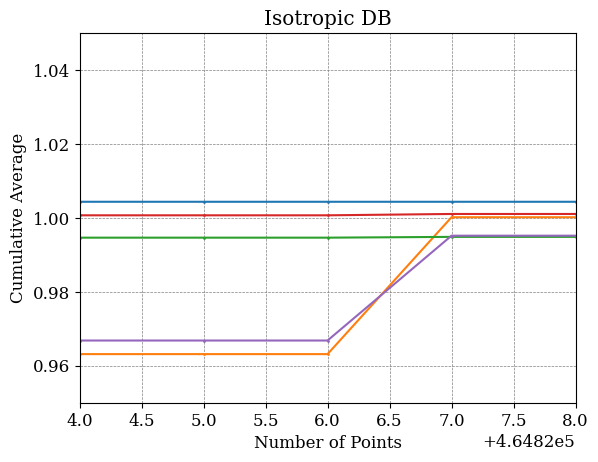

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-iso-2M-from-file.npy')
        print("Loaded existing processed data from 'AtA-iso-2M-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-grid-iso-2M-t33.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((5, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)

    # Save results
    np.save('AtA-iso-2M-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-iso-2M-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')

# Adding title and labels
plt.title('Isotropic DB')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
#plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0.95, top=1.05)  # Adjust 'top' to your desired maximum value
plt.xlim(left=464824, right=464828)


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
#custom_xticks = [0, 400000, 800000, 1200000, 1600000, 2000000]  # Custom tick positions
#custom_xticklabels = ['0','$4\cdot 10^5$', '$8\cdot 10^5$', '$12\cdot 10^5$', '$16\cdot 10^5$', '$20\cdot 10^5$']  # Custom tick labels
#plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-iso-2M-Napoleon.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Loaded existing processed data from 'AtA-iso-2M-from-file.npy'


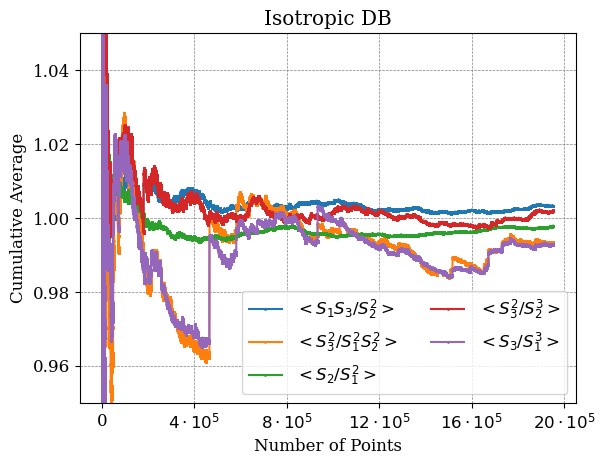

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-iso-2M-from-file.npy')
        print("Loaded existing processed data from 'AtA-iso-2M-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-grid-iso-2M-t33.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((5, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)

    # Save results
    np.save('AtA-iso-2M-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-iso-2M-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')

# Adding title and labels
plt.title('Isotropic DB')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0.95, top=1.05)  # Adjust 'top' to your desired maximum value
#plt.xlim(left=464824, right=464828)


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
custom_xticks = [0, 400000, 800000, 1200000, 1600000, 2000000]  # Custom tick positions
custom_xticklabels = ['0','$4\cdot 10^5$', '$8\cdot 10^5$', '$12\cdot 10^5$', '$16\cdot 10^5$', '$20\cdot 10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-iso-2M.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Loaded existing processed data from 'AtA-iso-2M-from-file.npy'


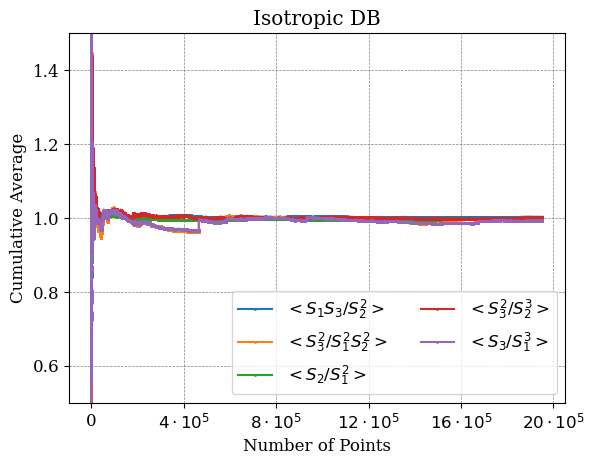

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-iso-2M-from-file.npy')
        print("Loaded existing processed data from 'AtA-iso-2M-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-grid-iso-2M-t33.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((5, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)

    # Save results
    np.save('AtA-iso-2M-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-iso-2M-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')

# Adding title and labels
plt.title('Isotropic DB')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value
#plt.xlim(left=464824, right=464828)


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
custom_xticks = [0, 400000, 800000, 1200000, 1600000, 2000000]  # Custom tick positions
custom_xticklabels = ['0','$4\cdot 10^5$', '$8\cdot 10^5$', '$12\cdot 10^5$', '$16\cdot 10^5$', '$20\cdot 10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-iso-2M.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

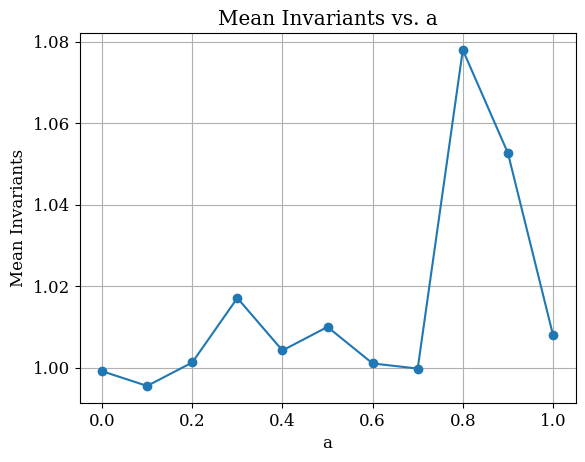

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[0, :] = s3 / (s1**3)
    inv[1, :] = s2 / (s1**2)
    inv[2, :] = (s3**2) / (s2**3)
    inv[3, :] = (s3**2) / (s1**2 * s2**2)
    inv[4, :] = (s1 * s3) / (s2**2)

    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(0, 1.1, 0.1)
    mean_invariants = []

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of the invariants
        mean_inv = np.mean(inv)
        mean_invariants.append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results
    plt.plot(a_values, mean_invariants, marker='o')
    plt.xlabel('a')
    plt.ylabel('Mean Invariants')
    plt.title('Mean Invariants vs. a')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

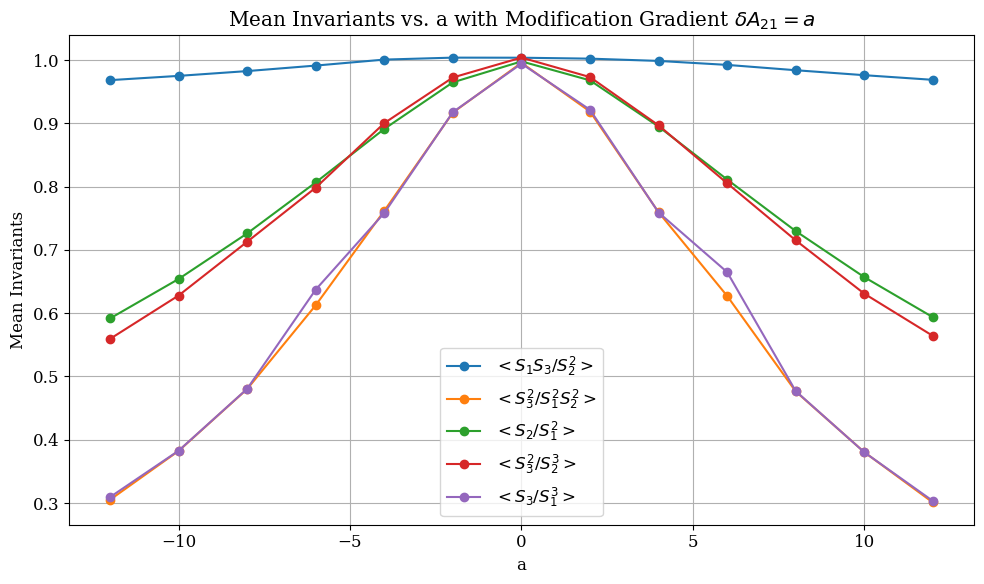

In [66]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{21}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A21.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

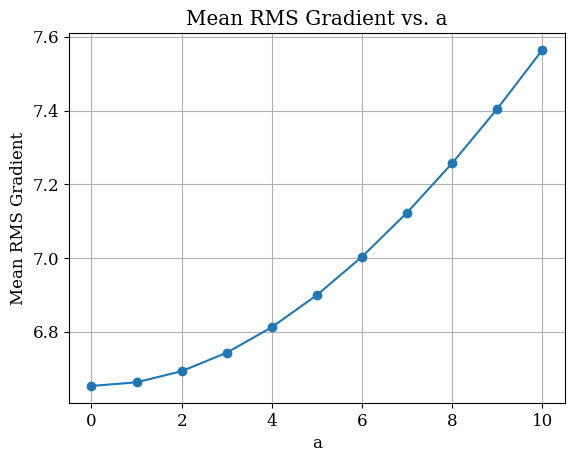

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_rms_gradient(grads):
    """Compute RMS gradient for each gradient matrix."""
    return np.sqrt(np.mean(grads**2, axis=(2, 3)))

def process_gradients(grads):
    """Process gradients with varying a and compute RMS gradient."""
    a_values = np.arange(0, 11, 1)
    rms_gradients = []

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute RMS gradient for the modified gradients
        rms_grad = compute_rms_gradient(modified_grads)
        
        # Calculate the mean of the RMS gradients
        mean_rms_grad = np.mean(rms_grad)
        rms_gradients.append(mean_rms_grad)

    return a_values, rms_gradients

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute RMS gradient
    a_values, rms_gradients = process_gradients(grads)

    # Plot the results
    plt.plot(a_values, rms_gradients, marker='o')
    plt.xlabel('a')
    plt.ylabel('Mean RMS Gradient')
    plt.title('Mean RMS Gradient vs. a')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

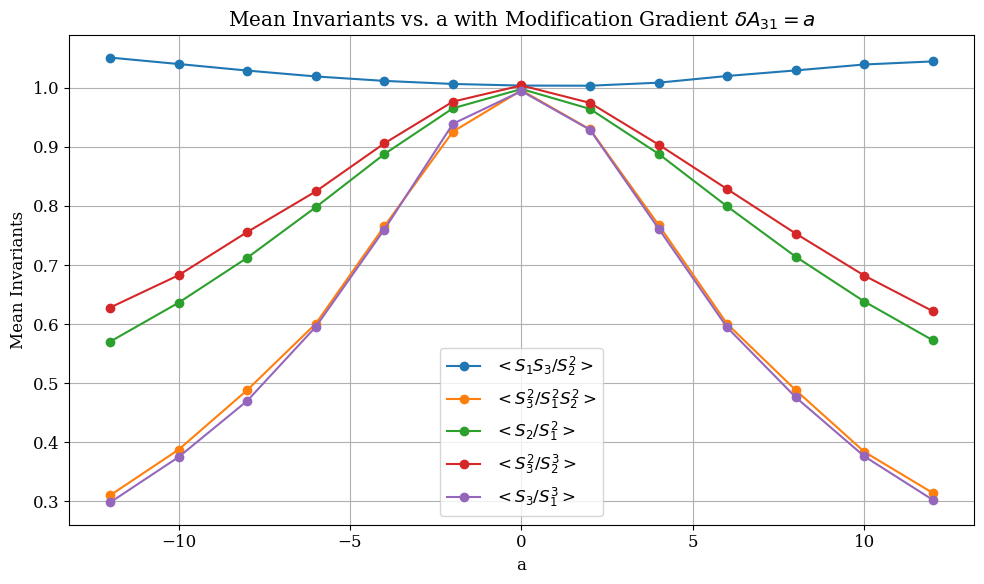

In [65]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 2] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{31}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A31.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

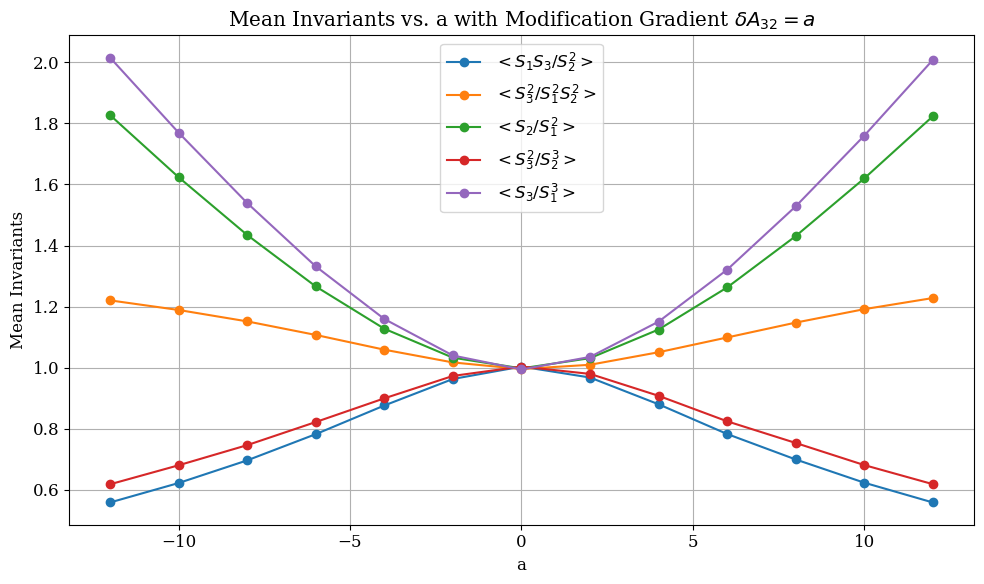

In [64]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[1, 2] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{32}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A32.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

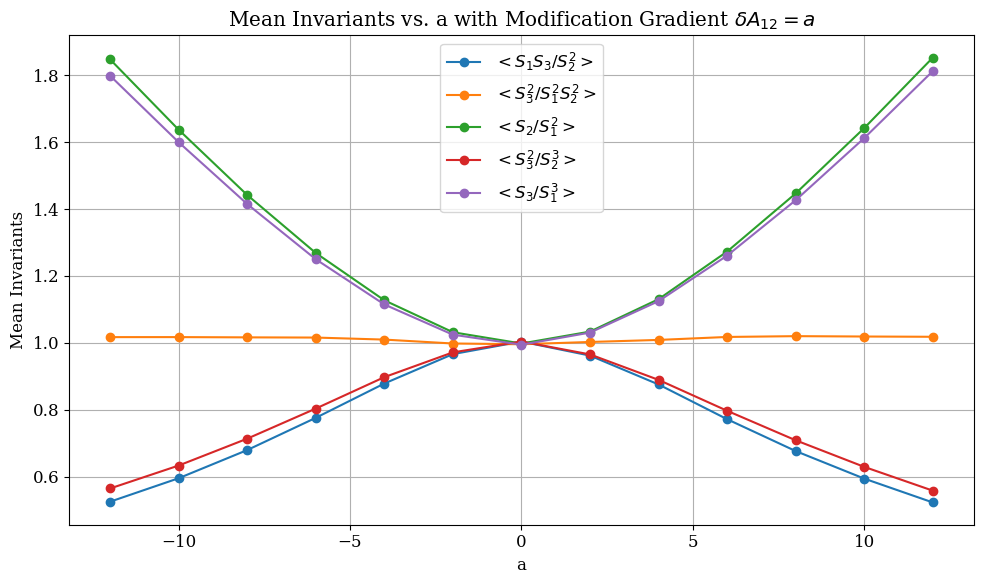

In [63]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[1, 0] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{12}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A12.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

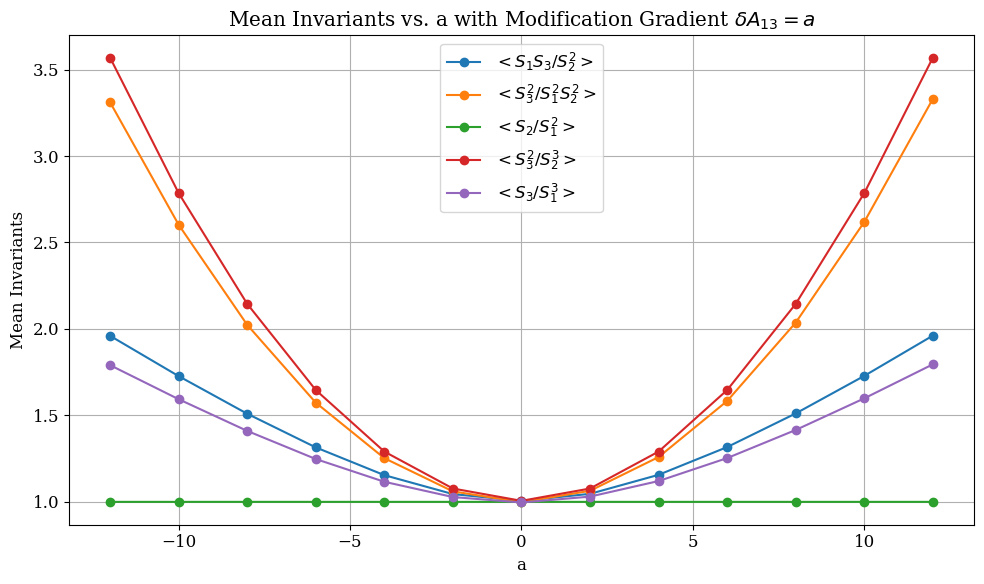

In [62]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[2, 0] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{13}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A13.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

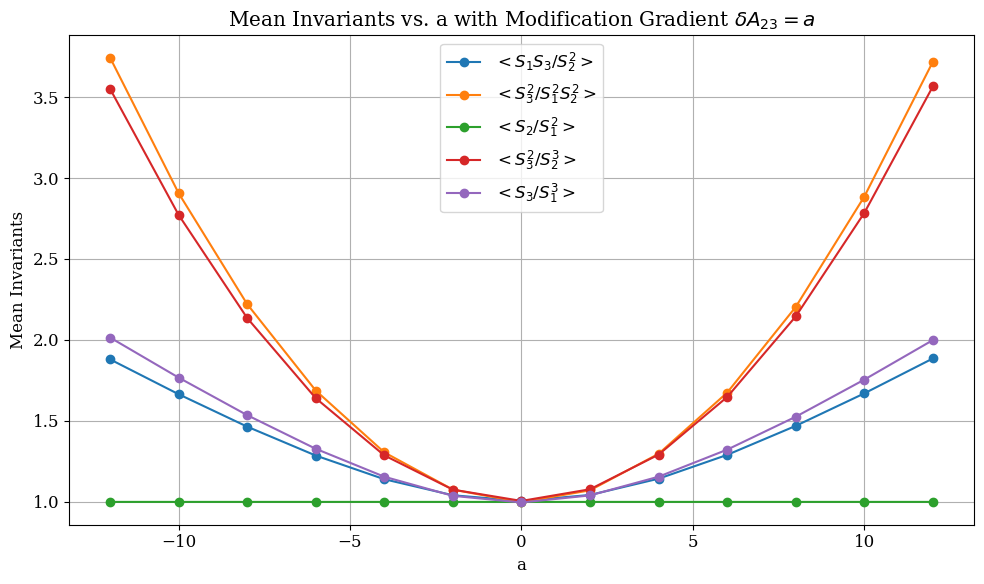

In [61]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[2, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{23}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A23.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

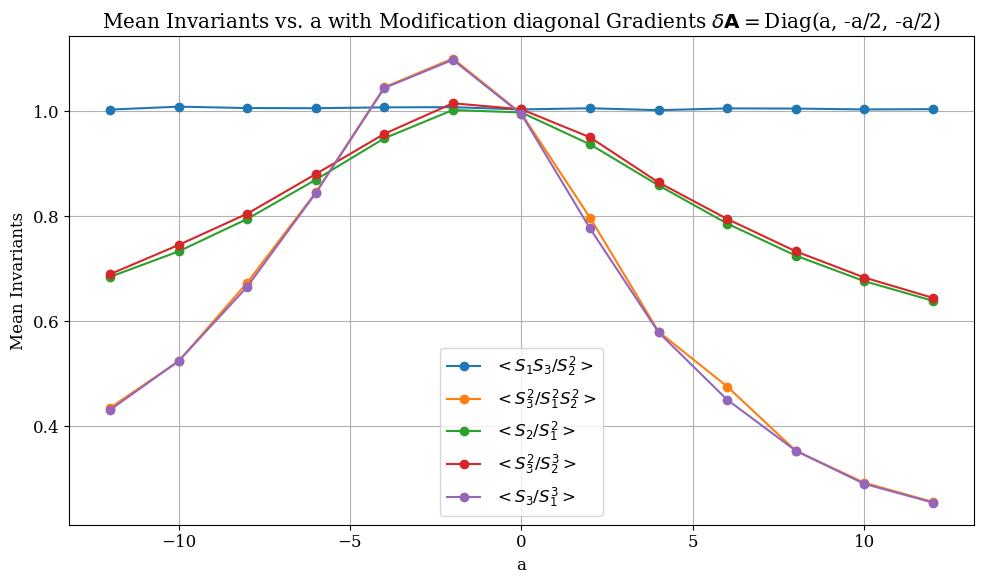

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive with a tolerance
    tolerance = 1e-10
    positive_definite_indices = np.all(eigenvalues > -tolerance, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)

    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 0] = a
        mod_matrix[1, 1] = -a/2
        mod_matrix[2, 2] = -a/2
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta\mathbf{A}=$Diag(a, -a/2, -a/2)"
    plt.title(f'Mean Invariants vs. a with Modification diagonal Gradients {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-Diag11.jpg', format='jpeg', dpi=300, bbox_inches='tight')
    
    plt.show()


if __name__ == "__main__":
    main()

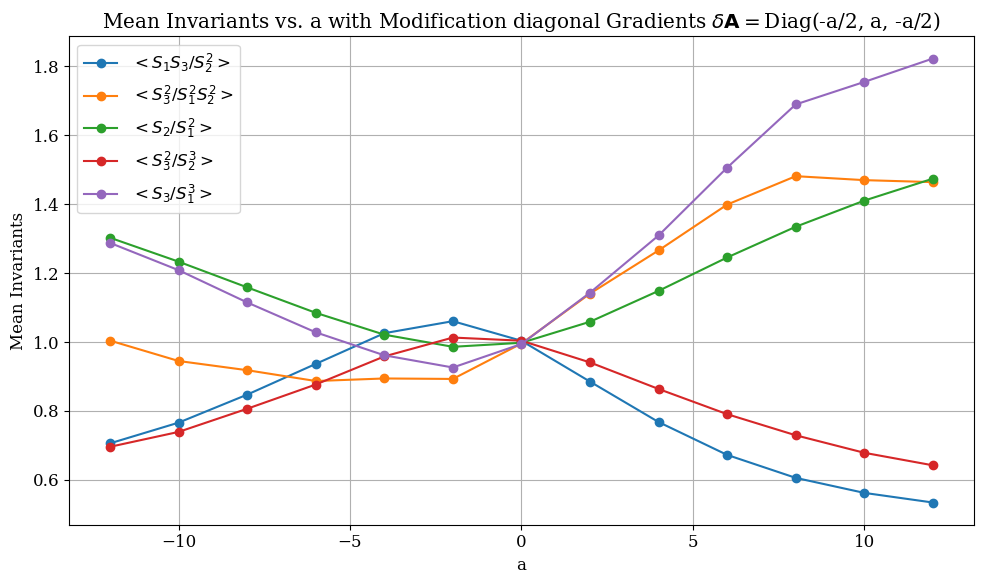

In [59]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive with a tolerance
    tolerance = 1e-10
    positive_definite_indices = np.all(eigenvalues > -tolerance, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)

    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 0] = -a/2
        mod_matrix[1, 1] = a
        mod_matrix[2, 2] = -a/2
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta\mathbf{A}=$Diag(-a/2, a, -a/2)"
    plt.title(f'Mean Invariants vs. a with Modification diagonal Gradients {mod_matrix_description}')
    plt.tight_layout()

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-Diag22.jpg', format='jpeg', dpi=300, bbox_inches='tight')
    
    plt.show()


if __name__ == "__main__":
    main()

<Figure size 640x480 with 0 Axes>

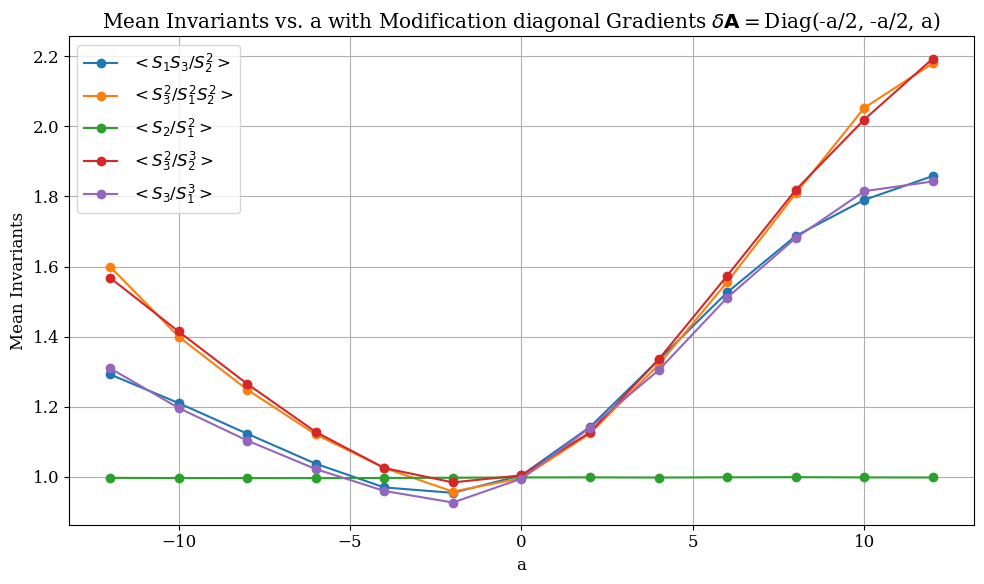

In [58]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive with a tolerance
    tolerance = 1e-10
    positive_definite_indices = np.all(eigenvalues > -tolerance, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)

    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 0] = -a/2
        mod_matrix[1, 1] = -a/2
        mod_matrix[2, 2] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta\mathbf{A}=$Diag(-a/2, -a/2, a)"
    plt.title(f'Mean Invariants vs. a with Modification diagonal Gradients {mod_matrix_description}')
    plt.tight_layout()

    # Save the plot
    plt.savefig('Iso-Modi-Diag33.jpg', format='jpeg', dpi=300, bbox_inches='tight')
    # print("Plot saved successfully.")
    
    plt.show()
    # print("Plot displayed successfully.")

if __name__ == "__main__":
    main()

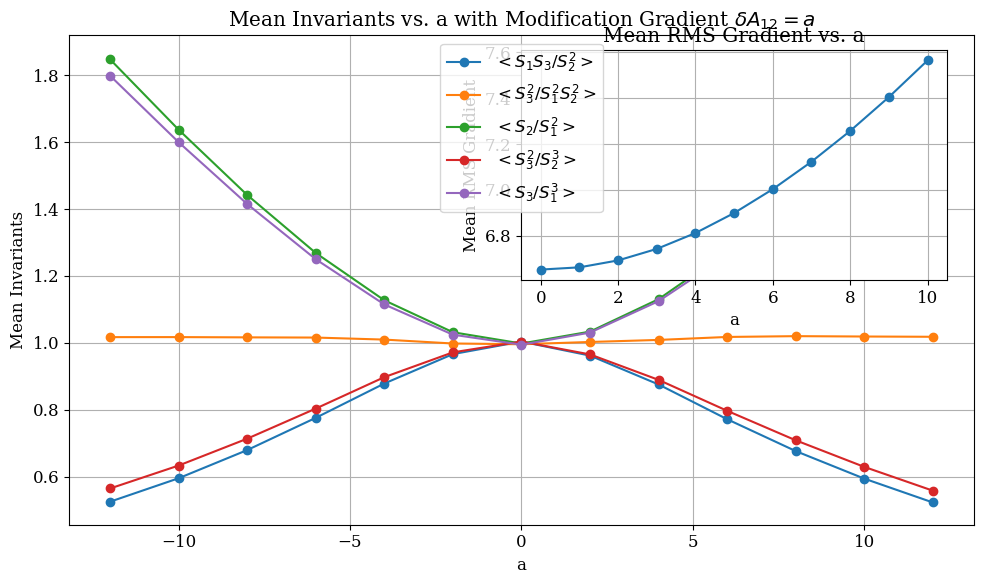

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[2, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[1, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[1, 0] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def compute_rms_gradient(grads):
    """Compute RMS gradient for each gradient matrix."""
    return np.sqrt(np.mean(grads**2, axis=(2, 3)))

def process_rms_gradients(grads):
    """Process gradients with varying a and compute RMS gradient."""
    a_values = np.arange(0, 11, 1)
    rms_gradients = []

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute RMS gradient for the modified gradients
        rms_grad = compute_rms_gradient(modified_grads)
        
        # Calculate the mean of the RMS gradients
        mean_rms_grad = np.mean(rms_grad)
        rms_gradients.append(mean_rms_grad)

    return a_values, rms_gradients

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Process gradients and compute RMS gradient
    a_values_rms, rms_gradients = process_rms_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{12}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Create inset for the RMS gradient plot
    axins = ax.inset_axes([0.5, 0.5, 0.47, 0.47])  # [left, bottom, width, height]
    axins.plot(a_values_rms, rms_gradients, marker='o')
    axins.set_xlabel('a')
    axins.set_ylabel('Mean RMS Gradient')
    axins.set_title('Mean RMS Gradient vs. a')
    axins.grid(True)

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A12.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

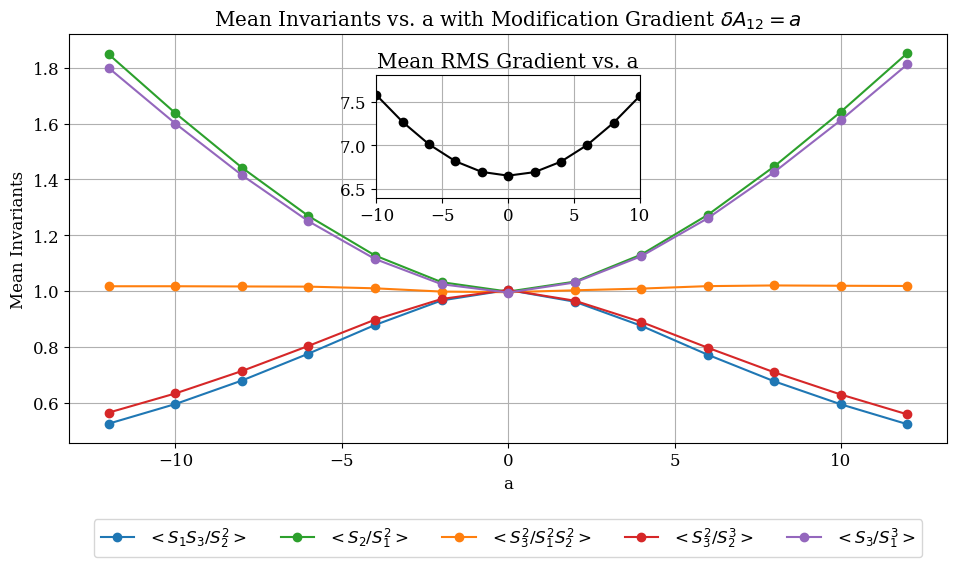

In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[4, :] = s3 / (s1**3)
    inv[1, :] = s2 / (s1**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[2, :] = (s3**2) / (s1**2 * s2**2)
    inv[0, :] = (s1 * s3) / (s2**2)
    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[1, 0] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def compute_rms_gradient(grads):
    """Compute RMS gradient for each gradient matrix."""
    return np.sqrt(np.mean(grads**2, axis=(2, 3)))

def process_rms_gradients(grads):
    """Process gradients with varying a and compute RMS gradient."""
    a_values = np.arange(-12, 14, 2)
    rms_gradients = []

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 1] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute RMS gradient for the modified gradients
        rms_grad = compute_rms_gradient(modified_grads)
        
        # Calculate the mean of the RMS gradients
        mean_rms_grad = np.mean(rms_grad)
        rms_gradients.append(mean_rms_grad)

    return a_values, rms_gradients

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Process gradients and compute RMS gradient
    a_values_rms, rms_gradients = process_rms_gradients(grads)

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]
    
    # Define the new order of colors manually
    colors = ['C0', 'C2', 'C1', 'C3', 'C4']

    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i], color=colors[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=5)
   
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta A_{12}=a$"
    plt.title(f'Mean Invariants vs. a with Modification Gradient {mod_matrix_description}')
    plt.tight_layout()

    # Create inset for the RMS gradient plot
    axins = ax.inset_axes([0.35, 0.6, 0.3, 0.3])  # [left, bottom, width, height]
    axins.plot(a_values_rms, rms_gradients, marker='o', color='black')
    #axins.set_xlabel('a')
    #axins.set_ylabel('Mean RMS Gradient')
    axins.set_title('Mean RMS Gradient vs. a')
    axins.grid(True)
    axins.set_xlim(-10, 10)
    axins.set_ylim(6.4, 7.8)

    # Saving the plot as a JPEG file
    plt.savefig('Iso-Modi-A12.jpg', format='jpeg', dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

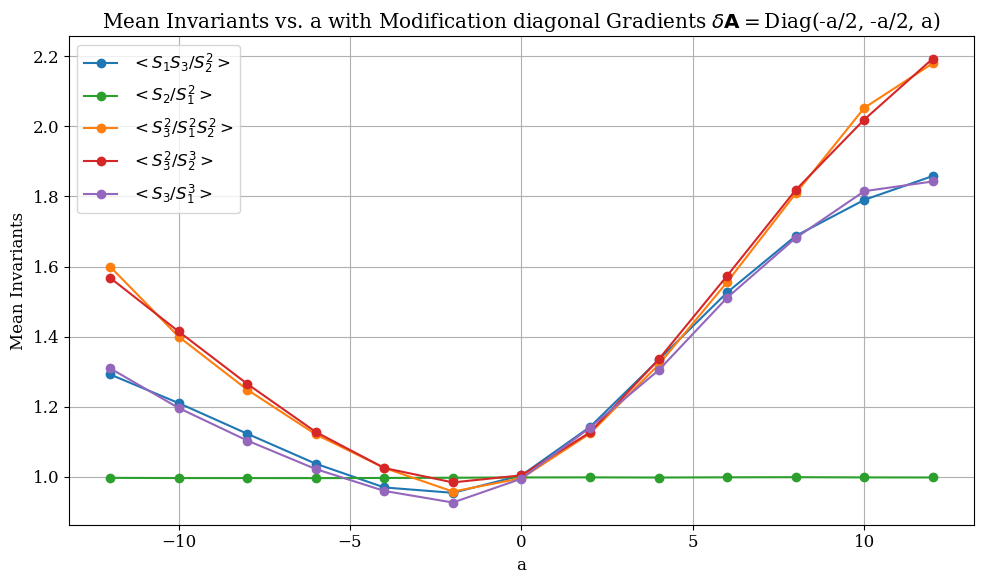

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def compute_invariants(grads):
    """Compute invariants from gradient data."""
    # Calculate Gamma
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
    
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive with a tolerance
    tolerance = 1e-10
    positive_definite_indices = np.all(eigenvalues > -tolerance, axis=-1)
    Gamma = Gamma[positive_definite_indices]
    
    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]

    # Calculate invariant ratios
    inv = np.zeros((5, len(s1)), dtype=np.float32)
    inv[0, :] = (s1 * s3) / (s2**2)
    inv[1, :] = s2 / (s1**2)
    inv[2, :] = (s3**2) / (s1**2 * s2**2)
    inv[3, :] = (s3**2) / (s2**3)
    inv[4, :] = s3 / (s1**3)

    return inv

def process_gradients(grads):
    """Process gradients with varying a and compute invariants."""
    a_values = np.arange(-12, 14, 2)
    mean_invariants = [[] for _ in range(5)]

    for a in a_values:
        # Create the modification matrix
        mod_matrix = np.zeros_like(grads[0, 0, :, :])
        mod_matrix[0, 0] = -a/2
        mod_matrix[1, 1] = -a/2
        mod_matrix[2, 2] = a
        
        # Add the modification matrix to each gradient matrix
        modified_grads = grads + mod_matrix
        
        # Compute invariants for the modified gradients
        inv = compute_invariants(modified_grads)
        
        # Calculate the mean of each invariant
        for i in range(5):
            mean_inv = np.mean(inv[i, :])
            mean_invariants[i].append(mean_inv)

    return a_values, mean_invariants

def main():
    try:
        grads = np.load('gradients-grid-iso-2M-t33.npy')
    except FileNotFoundError:
        raise FileNotFoundError("Gradient data file 'gradients-grid-iso-2M-t33.npy' not found.")

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Process gradients and compute invariants
    a_values, mean_invariants = process_gradients(grads)

    # Define the new order of labels
    labels = [
        f'$<S_1 S_3/S_2^2>$',
        f'$<S_2/S_1^2>$',
        f'$<S_3^2/S_1^2 S_2^2>$',
        f'$<S_3^2/S_2^3>$',
        f'$<S_3/S_1^3>$'
    ]

    # Define the new order of colors manually
    colors = ['C0', 'C2', 'C1', 'C3', 'C4']

    # Plot the results on a single plot with a legend
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(5):
        ax.plot(a_values, mean_invariants[i], marker='o', label=labels[i], color=colors[i])
    ax.grid(True)
    ax.set_xlabel('a')
    ax.set_ylabel('Mean Invariants')
    ax.legend()
    
    # Describe the structure of the modification matrix
    mod_matrix_description = "$\delta\mathbf{A}=$Diag(-a/2, -a/2, a)"
    plt.title(f'Mean Invariants vs. a with Modification diagonal Gradients {mod_matrix_description}')
    plt.tight_layout()

    # Save the plot
    plt.savefig('Iso-Modi-Diag33.jpg', format='jpeg', dpi=300, bbox_inches='tight')
    # print("Plot saved successfully.")
    
    plt.show()
    # print("Plot displayed successfully.")

if __name__ == "__main__":
    main()

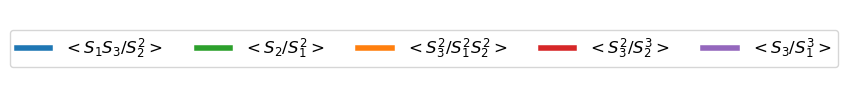

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Подписи для легенды
labels = [
    f'$<S_1 S_3/S_2^2>$',
    f'$<S_2/S_1^2>$',
    f'$<S_3^2/S_1^2 S_2^2>$',
    f'$<S_3^2/S_2^3>$',
    f'$<S_3/S_1^3>$'
]

# Список стандартных цветов с перестановкой второго и третьего цветов
standard_colors = ['C0', 'C2', 'C1'] + ['C{}'.format(i) for i in range(3, 10)]

# Создаем пустые объекты для легенды с использованием измененных стандартных цветов
handles = [Line2D([0], [0], color=standard_colors[i % len(standard_colors)], lw=4) for i in range(len(labels))]

# Создаем отдельную фигуру для легенды
fig, ax = plt.subplots(figsize=(6, 1))

# Добавляем горизонтальную легенду
ax.legend(handles, labels, loc='center', ncol=len(labels))

# Убираем оси и подписи
ax.axis('off')

# Save the plot
plt.savefig('Legend.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Показываем график
plt.show()